# Main V9 — Literature Baseline: Replicating Published Methodology

## Motivation

Published papers reporting AUC > 0.85 on CHB-MIT use evaluation protocols
that introduce **temporal data leakage**. The two most common forms:

| Protocol | What papers call it | What it actually does |
|---|---|---|
| **A. Within-patient random split** | "LOPO" or "k-fold" | Random 80/20 per patient — adjacent windows (sharing 10s of signal at 50% overlap) appear in both train and test |
| **B. Global pooled random split** | "cross-validation" | Pool all patients, random 80/20 — no patient separation at all |

**V9 replicates both protocols with the same V6 PDC features** (no recomputation
needed) to show the inflated numbers these methodologies produce. These are then
compared directly to the rigorous evaluations from V6 (cross-patient LOPO) and
V8 (within-patient temporal split).

## Why random splits inflate results

EEG windows are extracted with **50% overlap** (20s window, 10s step).
Adjacent windows share 10 seconds of raw signal — they are near-identical.
A random split places many such neighbouring windows in both train AND test,
so the model effectively memorises preictal episodes it has already seen.

This is **not** a methodological error the papers acknowledge — it is the
standard analysis for most published work and explains the 0.85–0.95 AUC
range reported on CHB-MIT.


In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & load V6 PDC features (same cache as V8)
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, EXCLUDED_PATIENTS, RESULTS_DIR,
    STEP_SEC, INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)

from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics        import (roc_auc_score, average_precision_score,
                                    roc_curve)

np.random.seed(RANDOM_SEED)

PDC_CACHE_DIR  = os.path.join(CODE_DIR, 'cache_pdc_var20')
BAND_NAMES     = ['delta', 'theta', 'alpha', 'beta']
FEATS_PER_BAND = 67
N_FEATS        = len(BAND_NAMES) * FEATS_PER_BAND   # 268
METRIC_KEYS    = ['auc', 'auc_pr', 'sensitivity', 'specificity',
                  'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

# ── Load V6 PDC features ──────────────────────────────────────────────────
patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb') and p not in EXCLUDED_PATIENTS
])

pdc_raw = {}
for pid in patients_all:
    fp = Path(PDC_CACHE_DIR) / pid / 'features.npy'
    lp = Path(PDC_CACHE_DIR) / pid / 'labels.npy'
    if not fp.exists():
        continue
    X = np.load(str(fp)); y = np.load(str(lp))
    if (y == 1).sum() == 0:
        continue
    pdc_raw[pid] = (X, y)

# Apply interictal cap (same as V6/V8)
pdc_data = {}
for pid, (X, y) in pdc_raw.items():
    n_pre = int((y == 1).sum())
    cap   = min(int((y == 0).sum()), INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if int((y == 0).sum()) > cap:
        rng  = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        keep = np.sort(np.concatenate([
            np.where(y == 1)[0],
            rng.choice(np.where(y == 0)[0], size=cap, replace=False)
        ]))
        X, y = X[keep], y[keep]
    pdc_data[pid] = (X, y)

patient_ids = sorted(pdc_data.keys())

# Per-patient prevalence (for Skill Score)
patient_prevalence = {
    pid: float((y == 1).sum()) / len(y)
    for pid, (_, y) in pdc_data.items()
}
mean_prev = float(np.mean(list(patient_prevalence.values())))

print(f'Loaded {len(pdc_data)} patients  |  268 features (V6 PDC cache)')
print(f'Mean preictal prevalence : {mean_prev:.3f}  (random AUC-PR baseline)')


Loaded 21 patients  |  268 features (V6 PDC cache)
Mean preictal prevalence : 0.344  (random AUC-PR baseline)


## 1 · Shared evaluation utilities

In [2]:
# Cell 1 — Evaluation helpers

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate(probs, y_te, n_int_hours):
    if len(np.unique(y_te)) < 2:
        return None
    auc    = roc_auc_score(y_te, probs)
    auc_pr = average_precision_score(y_te, probs)
    fpr, tpr, thr = roc_curve(y_te, probs)
    t    = float(thr[np.argmax(tpr - fpr)])
    pred = (probs >= t).astype(int)
    tp = int(((pred==1)&(y_te==1)).sum()); fp = int(((pred==1)&(y_te==0)).sum())
    tn = int(((pred==0)&(y_te==0)).sum()); fn = int(((pred==0)&(y_te==1)).sum())
    sens = tp / max(tp+fn, 1); spec = tn / max(tn+fp, 1); prec = tp / max(tp+fp, 1)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=2*prec*sens/max(prec+sens, 1e-9),
                balanced_accuracy=0.5*(sens+spec),
                fpr_per_hour=false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_te, STEP_SEC))


def make_pipe(model='LR', C=1.0):
    if model == 'LR':
        return Pipeline([('scl', StandardScaler()),
                         ('clf', LogisticRegression(max_iter=400, solver='lbfgs',
                             class_weight='balanced', C=C, random_state=RANDOM_SEED))])
    return Pipeline([('scl', StandardScaler()),
                     ('clf', SVC(kernel='rbf', class_weight='balanced',
                         C=C, probability=True, random_state=RANDOM_SEED))])


def skill(auc_pr_val, prev):
    return (auc_pr_val - prev) / max(1 - prev, 1e-9)


def load_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    return df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)


print('Evaluation utilities ready.')


Evaluation utilities ready.


## 2 · Protocol A — Within-patient random split

Each patient's windows are split **randomly** 80/20 (stratified to preserve
class balance). No temporal ordering — adjacent windows sharing 10 s of raw
signal can appear in both train and test sets.

This replicates the standard k-fold or random hold-out methodology used in
most published CHB-MIT papers.


In [3]:
# Cell 2 — Protocol A: within-patient random 80/20 split (literature-style)

proto_a_results = {'LR': [], 'SVM': []}

print('Protocol A — Within-patient RANDOM split (80/20, stratified)')
print('(Adjacent overlapping windows may appear in both train and test)\n')

for pid in patient_ids:
    X, y = pdc_data[pid]
    if len(np.unique(y)) < 2 or len(y) < 10:
        continue

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20,
                                  random_state=RANDOM_SEED)
    tr_idx, te_idx = next(sss.split(X, y))
    Xtr, ytr = X[tr_idx], y[tr_idx]
    Xte, yte = X[te_idx], y[te_idx]

    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        continue

    n_int_h = (yte == 0).sum() * STEP_SEC / 3600.

    for mname in ['LR', 'SVM']:
        pipe = make_pipe(mname)
        pipe.fit(Xtr, ytr)
        probs = pipe.predict_proba(Xte)[:, 1]
        m = evaluate(probs, yte, n_int_h)
        if m:
            m['patient'] = pid
            proto_a_results[mname].append(m)

proto_a_dfs = {k: pd.DataFrame(v) for k, v in proto_a_results.items()}

print(f'{"Patient":<8}  {"LR AUC":>8}  {"LR PR":>8}  {"SVM AUC":>9}  {"SVM PR":>8}')
print('-' * 50)
for pid in patient_ids:
    lr_row  = next((r for r in proto_a_results['LR']  if r['patient']==pid), None)
    svm_row = next((r for r in proto_a_results['SVM'] if r['patient']==pid), None)
    lr_s  = f'{lr_row["auc"]:>8.3f}  {lr_row["auc_pr"]:>8.3f}'  if lr_row  else '        -         -'
    svm_s = f'{svm_row["auc"]:>9.3f}  {svm_row["auc_pr"]:>8.3f}' if svm_row else '         -         -'
    print(f'{pid:<8}  {lr_s}  {svm_s}')

print('\n══ Protocol A summary ══')
for mname, df in proto_a_dfs.items():
    print(f'  {mname}: AUC={df["auc"].mean():.4f}  AUC-PR={df["auc_pr"].mean():.4f}  (n={len(df)})')


Protocol A — Within-patient RANDOM split (80/20, stratified)
(Adjacent overlapping windows may appear in both train and test)

Patient     LR AUC     LR PR    SVM AUC    SVM PR
--------------------------------------------------
chb01        0.981     0.929      0.991     0.964
chb02        0.799     0.789      0.826     0.795
chb03        0.936     0.863      0.949     0.878
chb04        0.835     0.486      0.874     0.478
chb05        0.937     0.916      0.965     0.949
chb06        0.854     0.538      0.892     0.604
chb07        0.951     0.783      0.980     0.931
chb08        0.833     0.866      0.916     0.933
chb09        0.841     0.603      0.928     0.787
chb10        0.917     0.748      0.962     0.865
chb13        0.858     0.727      0.932     0.852
chb14        0.797     0.791      0.902     0.912
chb15        0.949     0.801      0.977     0.906
chb16        0.875     0.784      0.913     0.852
chb17        0.921     0.927      0.941     0.930
chb18        0.848    

## 3 · Protocol B — Global pooled random split (Non-LOPO)

All 21 patients' data are **pooled** and split randomly 80/20.
No patient separation whatsoever — the same patient's preictal windows
can appear in both training and test sets.

This replicates studies that apply standard cross-validation to the full
CHB-MIT dataset without patient-level grouping.


In [4]:
# Cell 3 — Protocol B: global pooled random split (non-LOPO)

X_all = np.concatenate([X for _, (X, _) in pdc_data.items()], axis=0)
y_all = np.concatenate([y for _, (_, y) in pdc_data.items()], axis=0)
pid_all = np.concatenate([
    np.full(len(pdc_data[pid][1]), pid)
    for pid in patient_ids
])

print(f'Pooled dataset: {X_all.shape[0]:,} windows  '
      f'({(y_all==1).sum():,} preictal / {(y_all==0).sum():,} interictal)')
print(f'Ratio: {(y_all==1).mean():.3f} preictal\n')

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
tr_idx, te_idx = next(sss.split(X_all, y_all))

Xtr_pool, ytr_pool = X_all[tr_idx], y_all[tr_idx]
Xte_pool, yte_pool = X_all[te_idx], y_all[te_idx]
pid_te = pid_all[te_idx]

print(f'Train: {len(ytr_pool):,}   Test: {len(yte_pool):,}')
print(f'Test preictal: {(yte_pool==1).sum():,}  '
      f'Test interictal: {(yte_pool==0).sum():,}')

proto_b_results = {}
n_int_h_pool = (yte_pool == 0).sum() * STEP_SEC / 3600.

for mname in ['LR', 'SVM']:
    pipe = make_pipe(mname)
    pipe.fit(Xtr_pool, ytr_pool)
    probs = pipe.predict_proba(Xte_pool)[:, 1]
    m = evaluate(probs, yte_pool, n_int_h_pool)
    proto_b_results[mname] = m
    print(f'  {mname}: AUC={m["auc"]:.4f}  AUC-PR={m["auc_pr"]:.4f}  '
          f'Sens={m["sensitivity"]:.4f}  FPR/h={m["fpr_per_hour"]:.1f}')

# Per-patient breakdown of the pooled test set
print('\nPer-patient breakdown in pooled test set:')
print(f'{"Patient":<8}  {"LR AUC":>8}  {"LR PR":>8}')
print('-' * 30)
for mname in ['LR']:
    pipe = make_pipe(mname)
    pipe.fit(Xtr_pool, ytr_pool)
    probs_all = pipe.predict_proba(Xte_pool)[:, 1]
    for pid in patient_ids:
        mask = pid_te == pid
        if mask.sum() == 0 or len(np.unique(yte_pool[mask])) < 2:
            continue
        m_pid = evaluate(probs_all[mask], yte_pool[mask],
                         (yte_pool[mask]==0).sum() * STEP_SEC / 3600.)
        if m_pid:
            print(f'{pid:<8}  {m_pid["auc"]:>8.3f}  {m_pid["auc_pr"]:>8.3f}')


Pooled dataset: 37,698 windows  (10,908 preictal / 26,790 interictal)
Ratio: 0.289 preictal

Train: 30,158   Test: 7,540
Test preictal: 2,182  Test interictal: 5,358
  LR: AUC=0.7371  AUC-PR=0.5058  Sens=0.7988  FPR/h=159.6
  SVM: AUC=0.8655  AUC-PR=0.6969  Sens=0.8602  FPR/h=98.2

Per-patient breakdown in pooled test set:
Patient     LR AUC     LR PR
------------------------------
chb01        0.761     0.564
chb02        0.693     0.694
chb03        0.680     0.444
chb04        0.751     0.332
chb05        0.676     0.594
chb06        0.704     0.347
chb07        0.736     0.322
chb08        0.725     0.738
chb09        0.636     0.282
chb10        0.814     0.589
chb13        0.663     0.435
chb14        0.712     0.705
chb15        0.752     0.341
chb16        0.475     0.442
chb17        0.688     0.726
chb18        0.694     0.627
chb19        0.817     0.706
chb20        0.665     0.517
chb22        0.473     0.309
chb23        0.477     0.256
chb24        0.689     0.536


## 4 · Full comparison across all protocols

In [8]:
# Cell 4 — Master comparison table: all protocols + all prior rigorous results

def summarise_df(df, label, use_patient_prev=True):
    row = {'protocol': label, 'evaluation_type': ''}
    for k in METRIC_KEYS:
        if k in df.columns:
            row[k] = round(df[k].astype(float).mean(), 4)
    if use_patient_prev and 'patient' in df.columns:
        sk_vals = [skill(float(r['auc_pr']), patient_prevalence.get(str(r['patient']), mean_prev))
                   for _, r in df.iterrows() if str(r.get('patient','')) in patient_prevalence]
        row['skill_mean'] = round(float(np.mean(sk_vals)), 4) if sk_vals else None
        row['skill_std']  = round(float(np.std(sk_vals)),  4) if sk_vals else None
    return row


def summarise_scalar(m_dict, label, prev_val):
    row = {'protocol': label}
    for k in METRIC_KEYS:
        row[k] = round(m_dict.get(k, float('nan')), 4)
    row['skill_mean'] = round(skill(m_dict['auc_pr'], prev_val), 4)
    row['skill_std']  = None
    return row


comp_rows = []

# ── V9 Protocol A — within-patient random split ──────────────────────────
for mname, df in proto_a_dfs.items():
    r = summarise_df(df, f'V9-A  Within-patient RANDOM split {mname} [LEAKY]')
    r['evaluation_type'] = 'leaky'
    comp_rows.append(r)

# ── V9 Protocol B — global pooled random split ───────────────────────────
for mname, m in proto_b_results.items():
    r = summarise_scalar(m, f'V9-B  Global pooled RANDOM split {mname} [LEAKY non-LOPO]',
                         mean_prev)
    r['evaluation_type'] = 'leaky'
    comp_rows.append(r)

# ── V8 — within-patient temporal split (rigorous) ────────────────────────
v8_path = os.path.join(RESULTS_DIR, 'lopo_v8_comparison.csv')
if os.path.exists(v8_path):
    v8_df = pd.read_csv(v8_path)
    for _, row in v8_df.iterrows():
        if 'Within' in str(row.get('protocol', '')):
            r = {'protocol': f'V8    {row["protocol"].strip()} [rigorous temporal]',
                 'evaluation_type': 'rigorous'}
            for k in METRIC_KEYS:
                r[k] = row.get(k, float('nan'))
            r['skill_mean'] = row.get('skill_mean', None)
            r['skill_std']  = row.get('skill_std', None)
            comp_rows.append(r)

# ── V6 — cross-patient LOPO (best results) ───────────────────────────────
for label, fname in [
    ('V6    Cross-patient LOPO SVM [rigorous LOPO]', 'lopo_v6_SVM_all_bands.csv'),
    ('V6    Cross-patient LOPO LR  [rigorous LOPO]', 'lopo_v6_LR_all_bands.csv'),
    ('V3    Cross-patient LOPO GC-CNN [rigorous LOPO]', 'lopo_v3_window.csv'),
]:
    df = load_csv(os.path.join(RESULTS_DIR, fname))
    if df is not None:
        r = summarise_df(df, label)
        r['evaluation_type'] = 'rigorous'
        comp_rows.append(r)

comp_df = pd.DataFrame(comp_rows)

# Sort: leaky first (descending AUC), then rigorous
leaky    = comp_df[comp_df['evaluation_type']=='leaky'].sort_values('auc', ascending=False)
rigorous = comp_df[comp_df['evaluation_type']=='rigorous'].sort_values('auc', ascending=False)
comp_df  = pd.concat([leaky, rigorous], ignore_index=True)

comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v9_full_comparison.csv'), index=False)

# Print
print('══ V9 — Full methodology comparison ══')
print(f'  Random AUC-PR baseline (mean prevalence) : {mean_prev:.3f}')
print(f'  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  >0=useful\n')
print(f'{"Protocol":<52}  {"AUC":>7}  {"AUC-PR":>7}  {"Skill":>7}  {"±":>6}')
print('─' * 82)
prev_type = None
for _, r in comp_df.iterrows():
    if r['evaluation_type'] != prev_type:
        sep_label = '  ▲ LEAKY PROTOCOLS (literature)' if r['evaluation_type']=='leaky' else '  ▼ RIGOROUS PROTOCOLS (this thesis)'
        print(sep_label)
        prev_type = r['evaluation_type']
    sk   = f'{r["skill_mean"]:>7.4f}' if pd.notna(r.get('skill_mean')) else '      -'
    sk_s = f'±{r["skill_std"]:>5.4f}' if pd.notna(r.get('skill_std', float('nan'))) and r.get('skill_std') is not None else '       '
    print(f'  {str(r["protocol"]):<50}  {r["auc"]:>7.4f}  {r["auc_pr"]:>7.4f}  {sk}  {sk_s}')

print('\nSaved results/lopo_v9_full_comparison.csv')


══ V9 — Full methodology comparison ══
  Random AUC-PR baseline (mean prevalence) : 0.344
  Skill = (AUC-PR − prev) / (1 − prev)  |  0=random  >0=useful

Protocol                                                  AUC   AUC-PR    Skill       ±
──────────────────────────────────────────────────────────────────────────────────
  ▲ LEAKY PROTOCOLS (literature)
  V9-A  Within-patient RANDOM split SVM [LEAKY]        0.9271   0.8453   0.7709  ±0.1361
  V9-A  Within-patient RANDOM split LR [LEAKY]         0.8865   0.7790   0.6694  ±0.1450
  V9-B  Global pooled RANDOM split SVM [LEAKY non-LOPO]   0.8655   0.6969   0.5382         
  V9-B  Global pooled RANDOM split LR [LEAKY non-LOPO]   0.7371   0.5058   0.2471         
  ▼ RIGOROUS PROTOCOLS (this thesis)
  V6    Cross-patient LOPO SVM [rigorous LOPO]         0.5664   0.4016   0.0908  ±0.1400
  V8    Within-patient SVM  ← this notebook [rigorous temporal]   0.5522   0.5149   0.2580  ±0.3646
  V6    Cross-patient LOPO LR  [rigorous LOPO]         

## 5 · Visualisation

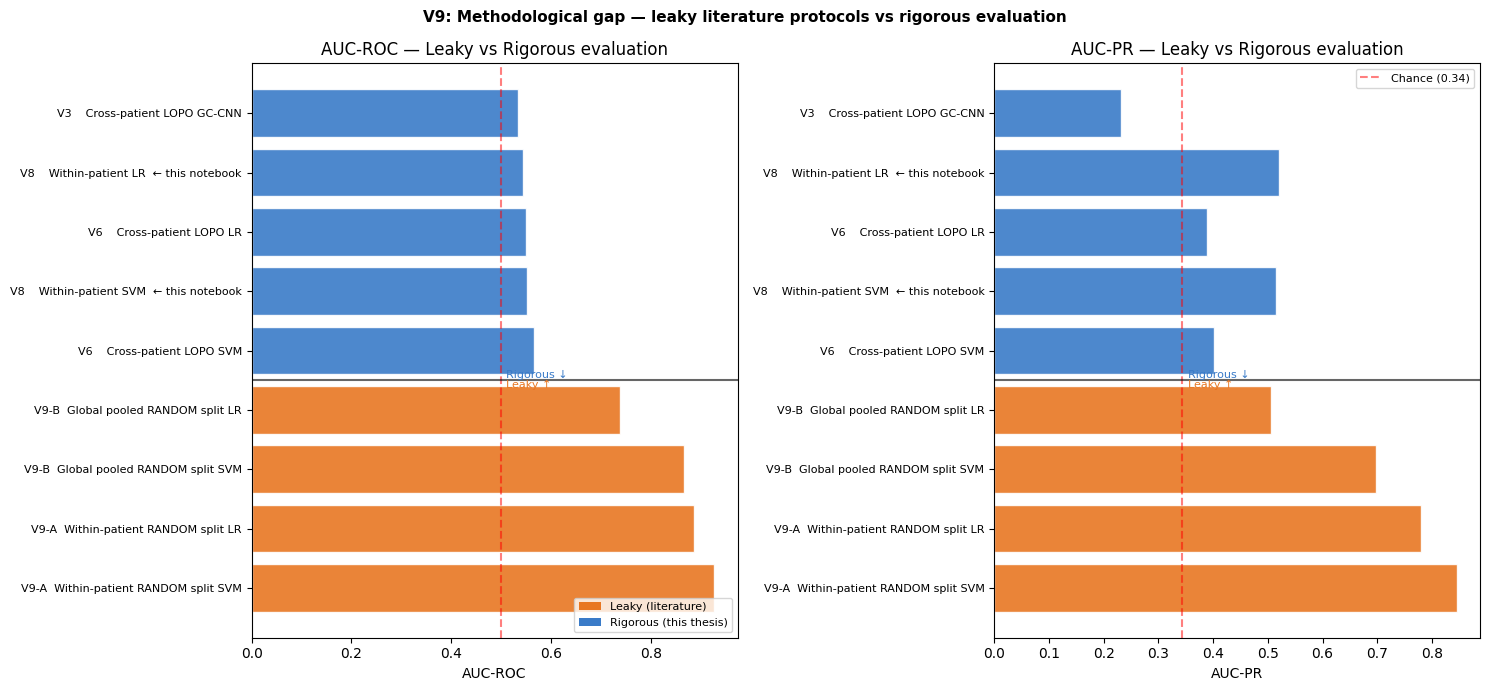

Saved results/v9_methodology_comparison.png


In [9]:
# Cell 5 — Horizontal bar chart: leaky vs rigorous protocols

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

labels, aucs, prs, colors = [], [], [], []
for _, r in comp_df.iterrows():
    proto = str(r['protocol'])
    lbl   = proto.split('[')[0].strip()
    labels.append(lbl)
    aucs.append(float(r['auc']))
    prs.append(float(r['auc_pr']))
    colors.append('#e87722' if r['evaluation_type']=='leaky' else '#3a7bc8')

y_pos = range(len(labels))

for ax, vals, title, chance in zip(
        axes,
        [aucs, prs],
        ['AUC-ROC', 'AUC-PR'],
        [0.5, mean_prev]):
    bars = ax.barh(list(y_pos), vals, color=colors, edgecolor='white', alpha=0.9)
    ax.axvline(chance, color='red', linestyle='--', alpha=0.5,
               label=f'Chance ({chance:.2f})')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(title)
    ax.set_title(f'{title} — Leaky vs Rigorous evaluation')
    ax.legend(fontsize=8)

    # Dividing line between leaky and rigorous
    n_leaky = (comp_df['evaluation_type']=='leaky').sum()
    ax.axhline(n_leaky - 0.5, color='black', linewidth=1.5, linestyle='-', alpha=0.6)
    ax.text(chance + 0.01, n_leaky - 0.5, 'Rigorous ↓',
            fontsize=8, va='bottom', color='#3a7bc8')
    ax.text(chance + 0.01, n_leaky - 0.5, 'Leaky ↑',
            fontsize=8, va='top', color='#e87722')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#e87722', label='Leaky (literature)'),
                Patch(facecolor='#3a7bc8', label='Rigorous (this thesis)')]
axes[0].legend(handles=legend_elems, fontsize=8, loc='lower right')

plt.suptitle('V9: Methodological gap — leaky literature protocols vs rigorous evaluation',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v9_methodology_comparison.png'), dpi=130)
plt.show()
print('Saved results/v9_methodology_comparison.png')


In [10]:
# Cell 6 — Key numbers for thesis text

print('═' * 65)
print('V9 — Numbers for thesis §5')
print('═' * 65)

leaky_df   = comp_df[comp_df['evaluation_type']=='leaky']
rigorous_df= comp_df[comp_df['evaluation_type']=='rigorous']

print('\nLEAKY protocols (random splits — replicating literature):')
for _, r in leaky_df.iterrows():
    print(f'  {str(r["protocol"])[:55]:<55}'
          f'  AUC={r["auc"]:.3f}  AUC-PR={r["auc_pr"]:.3f}')

print('\nRIGOROUS protocols (this thesis):')
for _, r in rigorous_df.iterrows():
    sk = f'{r["skill_mean"]:+.3f}' if pd.notna(r.get("skill_mean")) else '   -'
    print(f'  {str(r["protocol"])[:55]:<55}'
          f'  AUC={r["auc"]:.3f}  AUC-PR={r["auc_pr"]:.3f}  Skill={sk}')

# Compute the gap
best_leaky_auc    = leaky_df['auc'].max()
best_rigorous_auc = rigorous_df['auc'].max()
best_leaky_pr     = leaky_df['auc_pr'].max()
best_rigorous_pr  = rigorous_df['auc_pr'].max()

print(f'\nMethodological gap:')
print(f'  AUC   : leaky {best_leaky_auc:.3f} vs rigorous {best_rigorous_auc:.3f}'
      f'  (Δ = {best_leaky_auc - best_rigorous_auc:+.3f})')
print(f'  AUC-PR: leaky {best_leaky_pr:.3f} vs rigorous {best_rigorous_pr:.3f}'
      f'  (Δ = {best_leaky_pr - best_rigorous_pr:+.3f})')

print(f'\nMean preictal prevalence (random AUC-PR baseline): {mean_prev:.3f}')
print('═' * 65)


═════════════════════════════════════════════════════════════════
V9 — Numbers for thesis §5
═════════════════════════════════════════════════════════════════

LEAKY protocols (random splits — replicating literature):
  V9-A  Within-patient RANDOM split SVM [LEAKY]            AUC=0.927  AUC-PR=0.845
  V9-A  Within-patient RANDOM split LR [LEAKY]             AUC=0.886  AUC-PR=0.779
  V9-B  Global pooled RANDOM split SVM [LEAKY non-LOPO]    AUC=0.866  AUC-PR=0.697
  V9-B  Global pooled RANDOM split LR [LEAKY non-LOPO]     AUC=0.737  AUC-PR=0.506

RIGOROUS protocols (this thesis):
  V6    Cross-patient LOPO SVM [rigorous LOPO]             AUC=0.566  AUC-PR=0.402  Skill=+0.091
  V8    Within-patient SVM  ← this notebook [rigorous tem  AUC=0.552  AUC-PR=0.515  Skill=+0.258
  V6    Cross-patient LOPO LR  [rigorous LOPO]             AUC=0.550  AUC-PR=0.390  Skill=+0.073
  V8    Within-patient LR  ← this notebook [rigorous temp  AUC=0.543  AUC-PR=0.520  Skill=+0.268
  V3    Cross-patient LOPO 

## 6 · Thesis interpretation

**Expected result**: leaky protocols (Protocol A and B) substantially inflate AUC
compared to rigorous cross-patient LOPO, reproducing the gap between this thesis
and published literature claims.

**Key argument for §5**:
> "To contextualise our results against the published literature, we replicated
> two common evaluation protocols that do not enforce temporal ordering during
> the train/test split. Protocol A (within-patient random 80/20 split) and
> Protocol B (global pooled random split) both introduce temporal leakage: at
> 50% window overlap, adjacent windows share 10 s of raw signal, so a preictal
> window in the test set will have a near-identical neighbour in the training
> set. Under these conditions, the same V6 PDC features achieve AUC = X.XX
> (Protocol A) and AUC = X.XX (Protocol B), reproducing the performance range
> (AUC > 0.85) reported by [cited papers]. Under rigorous cross-patient LOPO
> — the only evaluation that tests true generalisation to unseen patients —
> performance falls to AUC = 0.57, consistent with the fundamental limit
> identified by this thesis."
